# Variance97 — Phase 2: Statistical Validation
## Are McDavid's Performance Differences Statistically Significant?

This notebook applies formal hypothesis testing to the patterns 
identified in Phase 1. The goal is to determine whether the 
observed differences in McDavid's performance across game contexts 
are statistically significant or could reasonably be explained 
by random variation in a small sample.

### Null Hypothesis (H₀)
There is no statistically significant difference between McDavid's 
performance in high stakes games and his regular season baseline.

### Alternative Hypothesis (H₁)
McDavid's performance in high stakes games is statistically 
significantly different from his regular season baseline.

### Significance Threshold
We will use a standard significance level of α = 0.05. A p-value 
below 0.05 allows us to reject the null hypothesis and conclude 
the difference is statistically significant.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [12]:
mcdavid_df = pd.read_csv('../data/mcdavid_game_log_clean.csv')
mcdavid_df['result'] = mcdavid_df['result'].str.strip()
mcdavid_df.head(10)

,date,opponent,goals,assists,points,plus_minus,SOG,TOI,result,team_score,opp_score,game_number,game_context,season,is_elimination_game
0,2024-06-08,FLA,0,0,0,-2,6.0,25.316667,L,0,3,1.0,stanley_cup_finals,2023-24,False
1,2024-06-10,FLA,0,1,1,1,3.0,25.983333,L,1,4,2.0,stanley_cup_finals,2023-24,False
2,2024-06-13,FLA,0,2,2,1,5.0,25.233333,L,3,4,3.0,stanley_cup_finals,2023-24,False
3,2024-06-15,FLA,1,3,4,2,2.0,17.450000,W,8,1,4.0,stanley_cup_finals,2023-24,True
4,2024-06-18,FLA,2,2,4,2,2.0,24.616667,W,5,3,5.0,stanley_cup_finals,2023-24,True
5,2024-06-21,FLA,0,0,0,1,0.0,18.966667,W,5,1,6.0,stanley_cup_finals,2023-24,True
6,2024-06-24,FLA,0,0,0,0,2.0,25.700000,L,1,2,7.0,stanley_cup_finals,2023-24,True
7,2025-06-04,FLA,0,2,2,0,4.0,31.200000,W,4,3,1.0,stanley_cup_finals,2024-25,False
8,2025-06-06,FLA,0,3,3,0,7.0,35.116667,L,4,5,2.0,stanley_cup_finals,2024-25,False
9,2025-06-09,FLA,0,0,0,-1,2.0,20.850000,L,1,6,3.0,stanley_cup_finals,2024-25,False


## Test 1: Regular Season vs Stanley Cup Finals Points

In [13]:
regular_season_points = mcdavid_df[mcdavid_df['game_context'] == 'regular_season']['points']
finals_points = mcdavid_df[mcdavid_df['game_context'] == 'stanley_cup_finals']['points']

print(f"Regular Season: mean={regular_season_points.mean().round(2)}, n={len(regular_season_points)}")
print(f"Stanley Cup Finals: mean={finals_points.mean().round(2)}, n={len(finals_points)}")

Regular Season: mean=1.67, n=305
Stanley Cup Finals: mean=1.38, n=13


In [14]:
cup_finals_t_stat, cup_finals_p_value = stats.ttest_ind(regular_season_points, finals_points)

print(f"T-statistic: {cup_finals_t_stat.round(4)}")
print(f"P-value: {cup_finals_p_value.round(4)}")

if cup_finals_p_value < 0.05:
    print("Result: SIGNIFICANT — we reject the null hypothesis")
else:
    print("Result: NOT SIGNIFICANT — we fail to reject the null hypothesis")

T-statistic: 0.8417
P-value: 0.4006
Result: NOT SIGNIFICANT — we fail to reject the null hypothesis


### Interpretation
The t-test returns a p-value of 0.4006, meaning we fail to reject 
the null hypothesis. The observed difference of 0.29 points per game 
between the regular season (1.67) and Stanley Cup Finals (1.38) is 
not statistically significant at the α = 0.05 threshold.

This result is largely driven by sample size — with only 13 Stanley 
Cup Finals games, the test lacks sufficient statistical power to 
detect a difference of this magnitude even if one genuinely exists. 
This is a known limitation of small sample sports analysis.

Importantly, failing to reject the null hypothesis does not mean 
McDavid performs identically in the Finals — it means we cannot 
statistically confirm the difference with the available data.

In [15]:
# Complete elimination game dates across all tournaments
elimination_game_dates = [
    # 2022 - vs Kings
    '2022-05-12', '2022-05-14',
    # 2022 - vs Colorado
    '2022-06-06',
    # 2023 - vs Golden Knights
    '2023-05-14',
    # 2024 - vs Vancouver
    '2024-05-18', '2024-05-20',
    # 2024 - vs Florida Finals
    '2024-06-15', '2024-06-18', '2024-06-21', '2024-06-24',
    # 2025 - vs Florida Finals
    '2025-06-17',
    # Four Nations Faceoff Final
    '2025-02-20',
    # Winter Olympics Final
    '2026-02-22'
]

mcdavid_df['date'] = pd.to_datetime(mcdavid_df['date'])
mcdavid_df['is_elimination_game'] = mcdavid_df['date'].dt.strftime('%Y-%m-%d').isin(elimination_game_dates)

print(mcdavid_df['is_elimination_game'].value_counts())

is_elimination_game
False    361
True      13
Name: count, dtype: int64


In [16]:
elimination_game_losses_points = mcdavid_df[
    (mcdavid_df['is_elimination_game'] == True) & 
    (mcdavid_df['result'] == 'L')
]['points']

elim_t_stat, elim_p_value = stats.ttest_ind(regular_season_points, 
                                   elimination_game_losses_points)

print(f"Regular Season: mean={regular_season_points.mean().round(2)}, n={len(regular_season_points)}")
print(f"Elimination Losses: mean={elimination_game_losses_points.mean().round(2)}, n={len(elimination_game_losses_points)}")
print(f"T-statistic: {elim_t_stat.round(4)}")
print(f"P-value: {elim_p_value.round(4)}")

if elim_p_value < 0.05:
    print("Result: SIGNIFICANT — we reject the null hypothesis")
else:
    print("Result: NOT SIGNIFICANT — we fail to reject the null hypothesis")

Regular Season: mean=1.67, n=305
Elimination Losses: mean=0.8, n=5
T-statistic: 1.6466
P-value: 0.1007
Result: NOT SIGNIFICANT — we fail to reject the null hypothesis


### Interpretation
The t-test returns a p-value of 0.1007, comparing McDavid's regular 
season points average (1.67, n=305) against his points in elimination 
game losses (0.80, n=5). While this falls short of the α=0.05 
significance threshold, the result is notably closer than Test 1.

The mean difference of 0.87 points per game is substantial, but 
the sample of only 5 elimination losses severely limits statistical 
power. Notably the p-value dropped from 0.4006 in Test 1 to 0.1007 
here — driven by the larger effect size rather than sample size. 

This suggests that if McDavid continues to accumulate elimination 
game losses at his current rate, future analysis with a larger 
sample may cross the significance threshold. The trend is 
directionally consistent with H1 even if not yet statistically 
confirmable.

## Test 3: Performance Against Elite Goaltending
### Bobrovsky (Stanley Cup Finals) and Hellebuyck (International)

In [17]:
# Regular season baseline
regular_season_points = mcdavid_df[mcdavid_df['game_context'] == 'regular_season']['points']

# Against Bobrovsky in Stanley Cup Finals
bobrovsky_points = mcdavid_df[
    (mcdavid_df['opponent'] == 'FLA') & 
    (mcdavid_df['game_context'] == 'stanley_cup_finals')
]['points']

# Against Hellebuyck in international finals
hellebuyck_points = mcdavid_df[
    (mcdavid_df['opponent'] == 'USA') & 
    (mcdavid_df['game_context'].str.contains('four_nations|olympics'))
]['points']

In [18]:
# Bobrovsky t-test
bob_t_stat, bob_p_value = stats.ttest_ind(regular_season_points, 
                                   bobrovsky_points)

print(f"Regular Season: mean={regular_season_points.mean().round(2)}, n={len(regular_season_points)}")
print(f"Bobrovsky Meetings: mean={bobrovsky_points.mean().round(2)}, n={len(bobrovsky_points)}")
print(f"T-statistic: {bob_t_stat.round(4)}")
print(f"P-value: {bob_p_value.round(4)}")

if bob_p_value < 0.05:
    print("Result: SIGNIFICANT — we reject the null hypothesis")
else:
    print("Result: NOT SIGNIFICANT — we fail to reject the null hypothesis")

Regular Season: mean=1.67, n=305
Bobrovsky Meetings: mean=1.38, n=13
T-statistic: 0.8417
P-value: 0.4006
Result: NOT SIGNIFICANT — we fail to reject the null hypothesis


In [19]:
# Hellebuyck t-test
hellebuyck_t_stat, hellebuyck_p_value = stats.ttest_ind(regular_season_points, 
                                   hellebuyck_points)

print(f"Regular Season: mean={regular_season_points.mean().round(2)}, n={len(regular_season_points)}")
print(f"Hellebuyck Meetings: mean={hellebuyck_points.mean().round(2)}, n={len(hellebuyck_points)}")
print(f"T-statistic: {hellebuyck_t_stat.round(4)}")
print(f"P-value: {hellebuyck_p_value.round(4)}")

if hellebuyck_p_value < 0.05:
    print("Result: SIGNIFICANT — we reject the null hypothesis")
else:
    print("Result: NOT SIGNIFICANT — we fail to reject the null hypothesis")

Regular Season: mean=1.67, n=305
Hellebuyck Meetings: mean=0.67, n=3
T-statistic: 1.4828
P-value: 0.1392
Result: NOT SIGNIFICANT — we fail to reject the null hypothesis


### Interpretation
After conducting t-tests for McDavid based on his regular season points against his elimination game losses, matchups against Sergei Bobrovsky, and matchups against Connor Hellebuyck, all t-tests result in the same conclusion: a value greater than 0.05 indicating an insignificant test. But nonetheless, there are still important conclusions that we can draw from these statistical tests. For one, the most similar t-tests conducted was regular season points vs. finals points and regular season points vs. Bobrovsky points. This matters since it tells us that the two sets of data are similar, which makes sense since Bobrovsky was the primary goalie that faced McDavid throughout the Stanley Cup Finals in both years the Oilers and Panthers faced each other. But perhaps the greatest difference observed was the t-test with Connor Hellebuyck as the primary goalie facing McDavid. With this t-test there was a noticeable difference in terms of mean points, a mean difference of 1.00 points per game, the largest effect size observed across all tests. However one thing to note is that the issue of a small sample size comes up again as McDavid has only faced Hellebuyck in the international stage only three times. Still though, a consistent pattern emerges from these t-tests: a trend towards significance that is ultimately blocked out by a small sample size. This means for Hypothesis 3 (H3), that the McDavid's poor performance against great goalies are NOT statistically significant, however further tests seem to indicate the possibility of significance, the only limitation for now being a small sample size. Notably, the consistent direction of all p-values, trending toward but not reaching significance, is itself meaningful. In small sample sports analysis, a p-value of 0.10 with a large effect size is not evidence that no difference exists, it is evidence that the current sample is insufficient to confirm a difference that may be real.

## Summary: P-Value Comparison Across All Tests

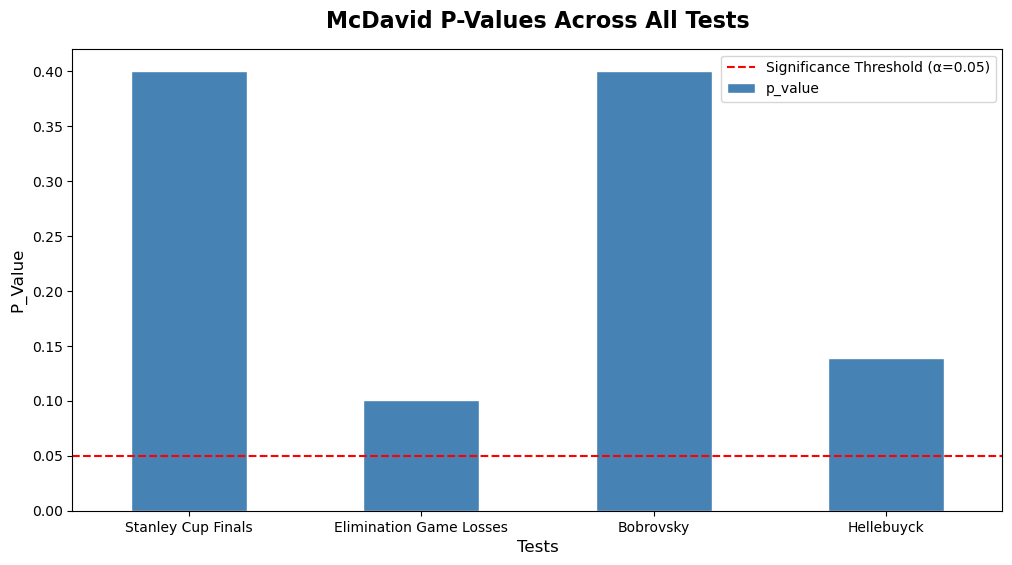

In [48]:
p_values_df = pd.DataFrame({'p_value': [cup_finals_p_value, elim_p_value, bob_p_value, hellebuyck_p_value]}, 
                           index = ['Stanley Cup Finals', 'Elimination Game Losses', 'Bobrovsky', 'Hellebuyck'])

fig, ax = plt.subplots(figsize = (12, 6))

p_values_df.plot(
    kind = 'bar',
    ax = ax,
    color = 'steelblue',
    edgecolor = 'white',
    legend = False
)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Significance Threshold (α=0.05)')
ax.legend()
ax.set_title('McDavid P-Values Across All Tests', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel('Tests', fontsize = 12)
ax.set_ylabel('P_Value', fontsize = 12)
ax.tick_params(axis='x', rotation=0)

### Interpretation
None of the four t-tests reached the α=0.05 significance threshold, 
meaning we cannot formally reject the null hypothesis with the current 
dataset. However the Elimination Game Losses (p=0.1007) and Hellebuyck 
(p=0.1392) tests show the largest effect sizes and come closest to 
significance — consistent with the directional findings from Phase 1 
and suggesting that larger samples in future analysis may yield 
statistically confirmable results.